In [1]:
"""
Notebook 05: Segmentation & Morphological Operations
=====================================================
Convert to notebook with: jupytext --to notebook notebooks/05_segmentation.py

Covers:
- Phase 7: Thresholding (Global, Adaptive, Otsu)
- Phase 7b: Multi-channel fusion & shadow suppression
- Phase 7c: Morphological cleanup
"""

'\nNotebook 05: Segmentation & Morphological Operations\n=====================================================\nConvert to notebook with: jupytext --to notebook notebooks/05_segmentation.py\n\nCovers:\n- Phase 7: Thresholding (Global, Adaptive, Otsu)\n- Phase 7b: Multi-channel fusion & shadow suppression\n- Phase 7c: Morphological cleanup\n'

# Notebook 05: Segmentation & Morphological Operations

**Course:** Digital Image Processing
**Project:** Automatic Parking Occupancy Estimation

---

## Objectives
1. Apply and compare three thresholding methods on slot patches
2. Demonstrate shadow suppression using HSV colour space
3. Implement multi-channel fusion (Otsu + Adaptive)
4. Clean binary masks using morphological operations
5. Visualize the full segmentation pipeline end-to-end


## 1. Setup & Imports


In [2]:
import sys, os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.path.abspath('.'))

import cv2
import numpy as np
import matplotlib
%matplotlib inline
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

from src.utils import load_config
from src.io_utils import list_frames, parse_pklot_xml
from src.geometry import load_homography, warp_perspective, transform_points
from src.roi import extract_slot_image, create_eroded_core_mask, load_slots_json
from src.preprocessing import preprocess_pipeline, to_grayscale, apply_clahe
from src.segmentation import (
    global_threshold, adaptive_threshold, otsu_threshold,
    shadow_suppress_hsv, fuse_channels
)
from src.morphology import (
    apply_erosion, apply_dilation, apply_opening, apply_closing,
    clean_binary_mask, morphology_grid
)
from src.visualize import show_and_save_fig

config = load_config('config/config.yaml')
hdata = load_homography('config/homography.npz')
H, output_size = hdata['H'], hdata['output_size']
bev_slots = load_slots_json('config/slots.json')

# Load a sunny frame (shadows are the hard case)
frames = list_frames(os.path.join('data/raw/PKLot', 'parking2'))
sunny_frames = [f for f in frames if f['weather'] == 'sunny']
sample = sunny_frames[len(sunny_frames)//2]

img = cv2.imread(sample['image_path'])
bev = warp_perspective(img, H, output_size)
gt_slots = parse_pklot_xml(sample['xml_path'])

# Build a lookup for ground truth
gt_lookup = {s['id']: s['occupied'] for s in gt_slots}

print(f"Frame: {sample['image_path']}")
print(f"Slots loaded: {len(bev_slots)}, GT labels: {len(gt_lookup)}")

Frame: data/raw/PKLot/parking2/sunny/2012-09-20/2012-09-20_14_04_35.jpg
Slots loaded: 100, GT labels: 100


## 2. Why Thresholding?

### Objective
Convert a grayscale image into a **binary mask** where white = "something
interesting" (car texture, edges, detail) and black = "background" (asphalt).

### Three Methods

| Method | OpenCV Call | How It Works |
|--------|-----------|-------------|
| **Global** | `cv2.threshold(img, T, 255, THRESH_BINARY)` | Fixed threshold T for entire image |
| **Adaptive** | `cv2.adaptiveThreshold(img, 255, ADAPTIVE_GAUSSIAN, THRESH_BINARY, blockSize, C)` | Different T for each pixel based on local neighbourhood |
| **Otsu** | `cv2.threshold(img, 0, 255, THRESH_BINARY + THRESH_OTSU)` | Automatically finds optimal T by maximising between-class variance |

### Limitations of a single method
- **Global** fails when illumination varies across the slot
- **Adaptive** handles local variation but is noisy
- **Otsu** is robust but assumes bimodal histogram (not always true)
- **Fusion** of multiple methods gives the best result


## 3. Thresholding Methods Comparison


In [3]:
# Pick one occupied and one vacant slot
occ_id = None
vac_id = None
for sid in bev_slots:
    if sid in gt_lookup:
        if gt_lookup[sid] == 1 and occ_id is None:
            occ_id = sid
        elif gt_lookup[sid] == 0 and vac_id is None:
            vac_id = sid
    if occ_id and vac_id:
        break

print(f"Occupied slot: {occ_id}, Vacant slot: {vac_id}")

Occupied slot: 2, Vacant slot: 1


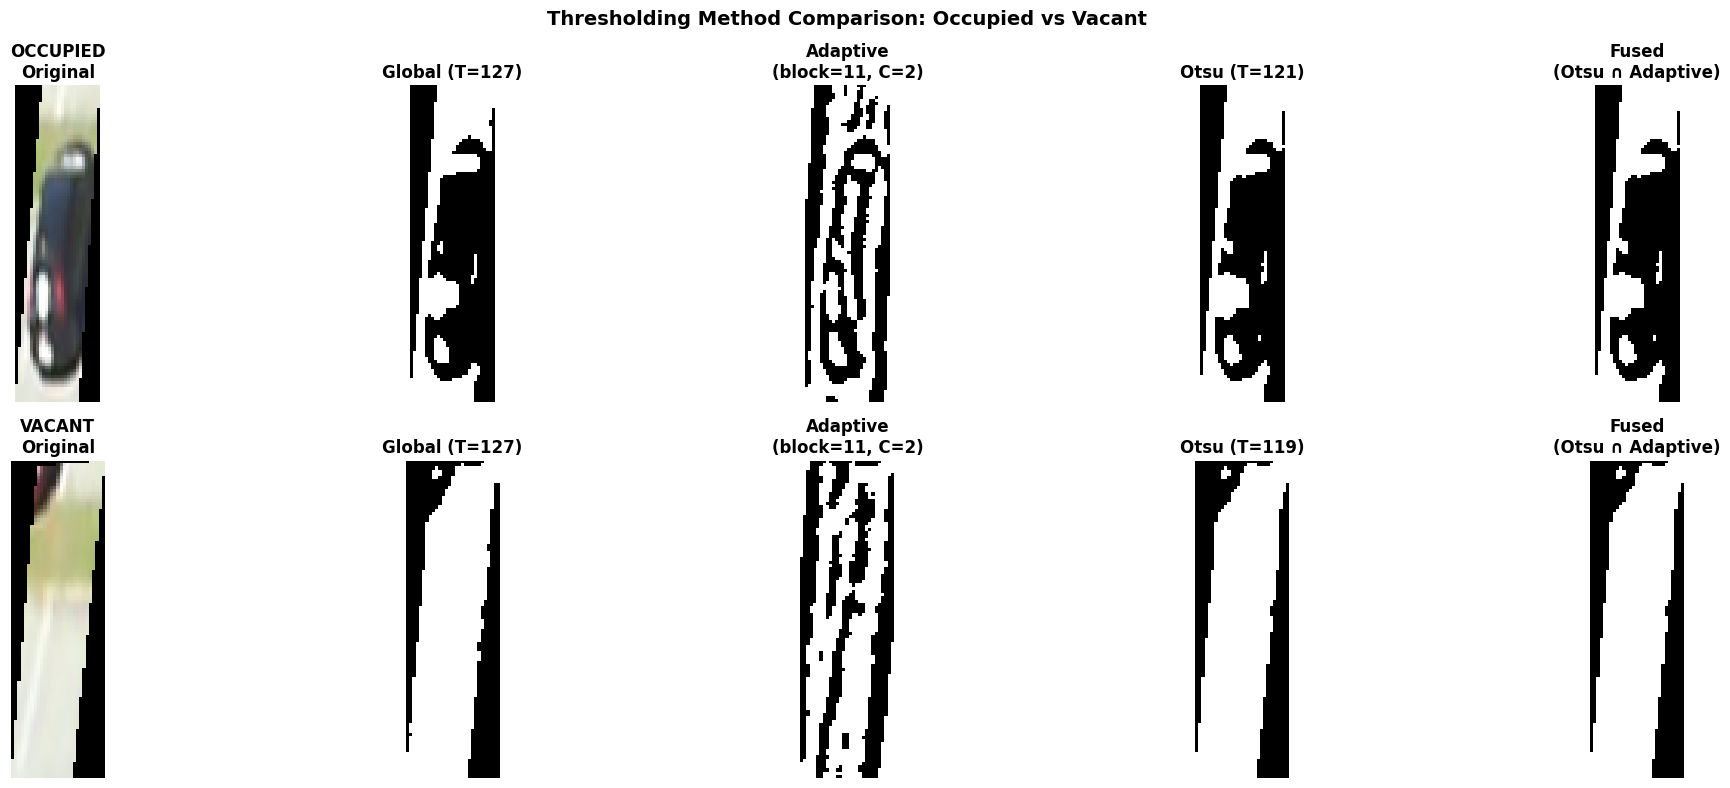

Saved: outputs/screenshots/09_thresholding_compare.png


In [4]:
# --- Compare all three thresholding methods ---
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for row, (sid, label) in enumerate([(occ_id, 'OCCUPIED'), (vac_id, 'VACANT')]):
    polygon = bev_slots[sid]
    patch, bbox, mask = extract_slot_image(bev, polygon)
    
    # Preprocess
    preprocessed = preprocess_pipeline(patch)
    
    # Thresholding methods
    global_bin, _ = global_threshold(preprocessed, thresh_value=127)
    adaptive_bin = adaptive_threshold(preprocessed, block_size=11, constant=2)
    otsu_bin, otsu_t, _ = otsu_threshold(preprocessed)
    
    # Fuse: Otsu AND Adaptive
    fused = fuse_channels(otsu_bin, adaptive_bin)
    
    # Display
    axes[row, 0].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'{label}\nOriginal', fontweight='bold')
    
    axes[row, 1].imshow(global_bin, cmap='gray')
    axes[row, 1].set_title(f'Global (T=127)', fontweight='bold')
    
    axes[row, 2].imshow(adaptive_bin, cmap='gray')
    axes[row, 2].set_title(f'Adaptive\n(block=11, C=2)', fontweight='bold')
    
    axes[row, 3].imshow(otsu_bin, cmap='gray')
    axes[row, 3].set_title(f'Otsu (T={otsu_t:.0f})', fontweight='bold')
    
    axes[row, 4].imshow(fused, cmap='gray')
    axes[row, 4].set_title(f'Fused\n(Otsu ∩ Adaptive)', fontweight='bold')
    
    for ax in axes[row]:
        ax.axis('off')

show_and_save_fig(fig,
                 'Thresholding Method Comparison: Occupied vs Vacant',
                 '09_thresholding_compare.png')

## 4. Shadow Suppression via HSV

### Shadows
Sunny frames produce **strong shadows** that cross slot boundaries.
In grayscale, shadows look like dark vehicle paint → false positives.

### HSV-based suppression
In HSV colour space, shadows have:
- **Low Value (V)** — they are dark
- **Low Saturation (S)** — they are grey, not colourful

By creating a shadow mask (low V AND low S) and subtracting it,
we can suppress shadows before thresholding.

```python
shadow_mask = (V < v_threshold) & (S < s_threshold)
cleaned = binary_mask & (~shadow_mask)
```


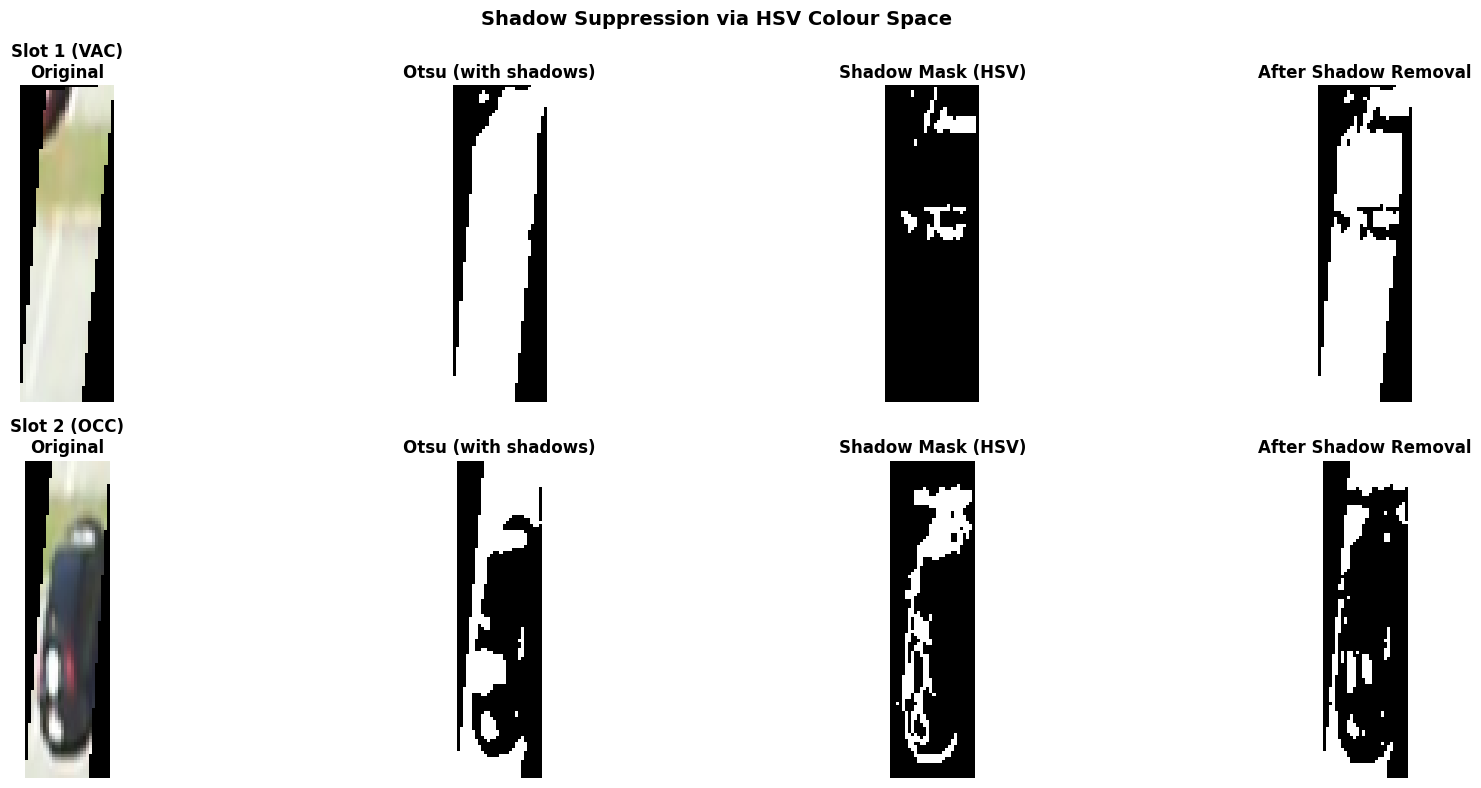

Saved: outputs/screenshots/09_shadow_suppression.png


In [5]:
# --- Shadow suppression demo ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Find a slot that likely has shadow (near the edge in sunny conditions)
shadow_slots = []
for sid in list(bev_slots.keys())[:20]:
    if sid in gt_lookup:
        shadow_slots.append(sid)

for row, sid in enumerate(shadow_slots[:2]):
    polygon = bev_slots[sid]
    patch, bbox, mask = extract_slot_image(bev, polygon)
    preprocessed = preprocess_pipeline(patch)
    
    # Without shadow suppression
    otsu_bin, _, _ = otsu_threshold(preprocessed)
    
    # With shadow suppression
    shadow_mask, non_shadow = shadow_suppress_hsv(patch, v_low=80, s_threshold=60)
    combined = cv2.bitwise_and(otsu_bin, non_shadow)
    
    label = 'OCC' if gt_lookup.get(sid, 0) else 'VAC'
    
    axes[row, 0].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'Slot {sid} ({label})\nOriginal', fontweight='bold')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(otsu_bin, cmap='gray')
    axes[row, 1].set_title('Otsu (with shadows)', fontweight='bold')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(shadow_mask, cmap='gray')
    axes[row, 2].set_title('Shadow Mask (HSV)', fontweight='bold')
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(combined, cmap='gray')
    axes[row, 3].set_title('After Shadow Removal', fontweight='bold')
    axes[row, 3].axis('off')

show_and_save_fig(fig, 'Shadow Suppression via HSV Colour Space',
                 '09_shadow_suppression.png')

## 5. Morphological Operations — Theory

### Set-Theoretic Definitions

Given binary image $A$ and structuring element $B$:

| Operation | Formula | Effect |
|-----------|---------|--------|
| **Erosion** | $A \ominus B = \{z \mid B_z \subseteq A\}$ | Shrinks white, removes small noise |
| **Dilation** | $A \oplus B = \{z \mid B_z \cap A \neq \emptyset\}$ | Grows white, fills small gaps |
| **Opening** | $A \circ B = (A \ominus B) \oplus B$ | Removes noise, preserves size |
| **Closing** | $A \bullet B = (A \oplus B) \ominus B$ | Fills holes, preserves size |

### OpenCV Functions
```python
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
eroded  = cv2.erode(img, kernel, iterations=1)
dilated = cv2.dilate(img, kernel, iterations=1)
opened  = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
closed  = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
```


## 6. Morphology Grid — All Operations on One Slot


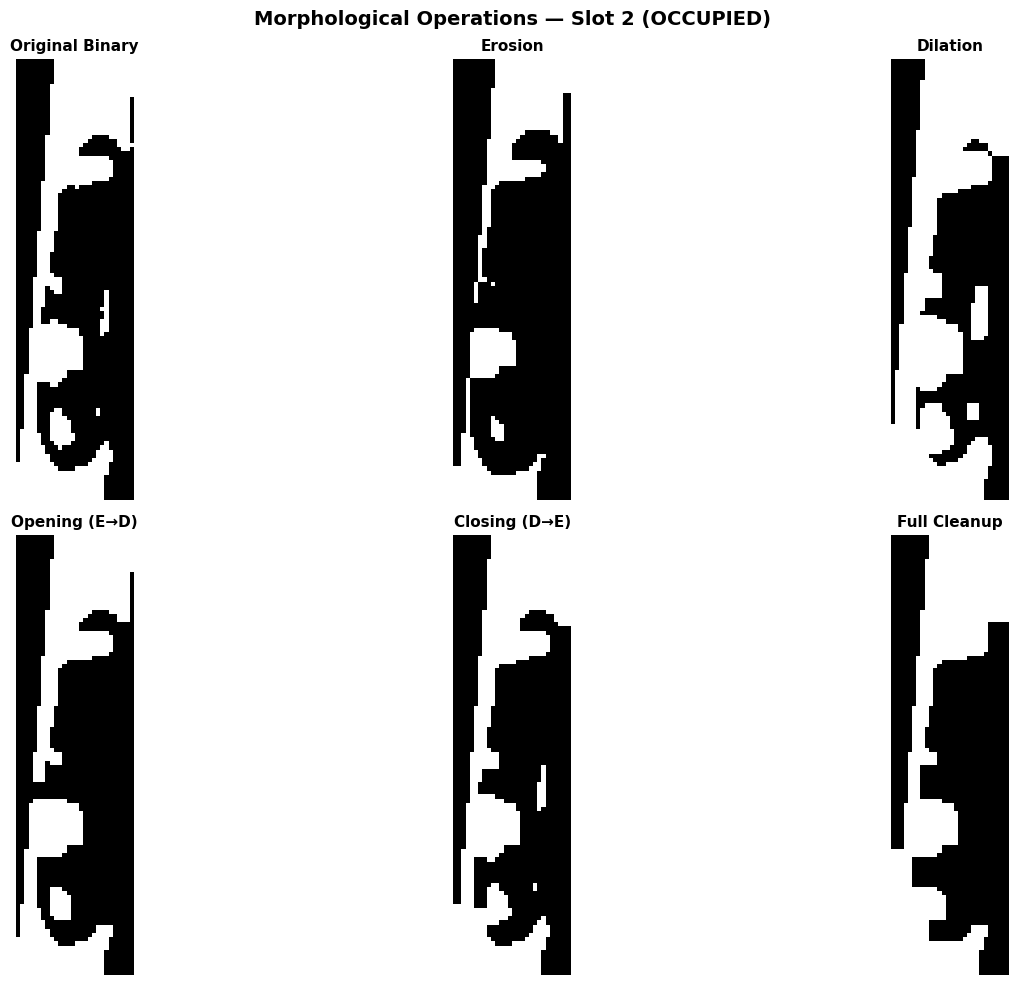

Saved: outputs/screenshots/10_morphology_stages.png


In [6]:
# --- Morphology grid for an occupied slot ---
polygon = bev_slots[occ_id]
patch, bbox, mask = extract_slot_image(bev, polygon)
preprocessed = preprocess_pipeline(patch)
otsu_bin, _, _ = otsu_threshold(preprocessed)

# Get all morphological stages
stages = morphology_grid(otsu_bin, kernel_size=(3, 3))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (name, stage_img) in enumerate(stages):
    r, c = divmod(idx, 3)
    axes[r, c].imshow(stage_img, cmap='gray')
    axes[r, c].set_title(name, fontsize=11, fontweight='bold')
    axes[r, c].axis('off')

show_and_save_fig(fig,
                 f'Morphological Operations — Slot {occ_id} (OCCUPIED)',
                 '10_morphology_stages.png')

## 7. Full Segmentation Pipeline: Raw → Cleaned Binary

Putting it all together: Preprocess → Otsu + Adaptive → Fuse → Morphology


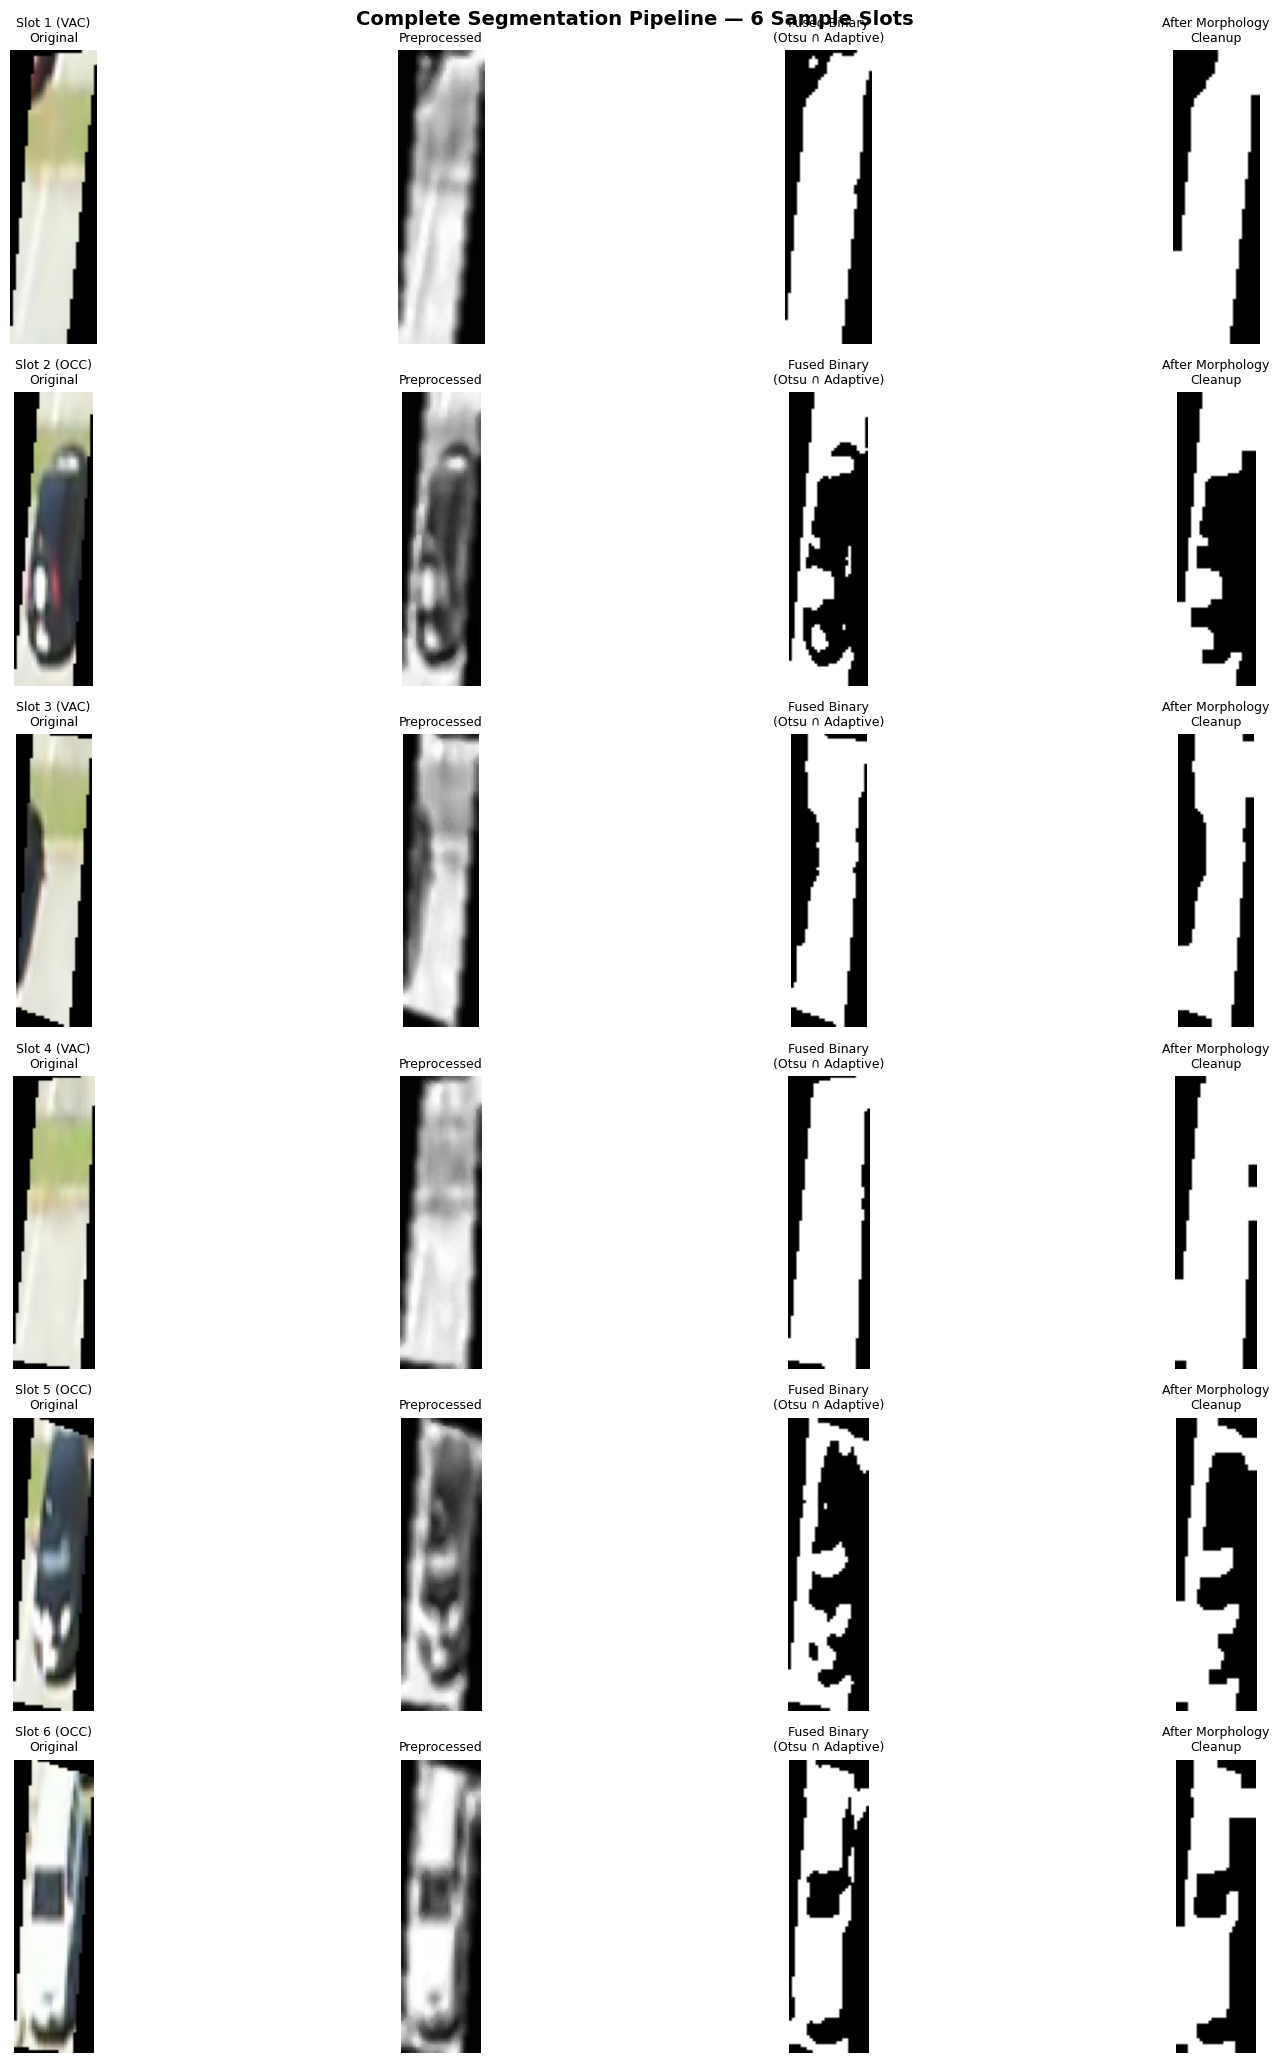

Saved: outputs/screenshots/10_full_segmentation_pipeline.png


In [7]:
# --- Full pipeline comparison: 6 slots ---
demo_slot_ids = list(bev_slots.keys())[:6]

fig, axes = plt.subplots(len(demo_slot_ids), 4, figsize=(18, len(demo_slot_ids)*3.5))

for row, sid in enumerate(demo_slot_ids):
    polygon = bev_slots[sid]
    patch, bbox, mask = extract_slot_image(bev, polygon)
    
    # Step 1: Preprocess
    preprocessed = preprocess_pipeline(patch)
    
    # Step 2: Threshold (multi-channel)
    otsu_bin, _, _ = otsu_threshold(preprocessed)
    adapt_bin = adaptive_threshold(preprocessed)
    fused = fuse_channels(otsu_bin, adapt_bin)
    
    # Step 3: Morphology cleanup
    cleaned = clean_binary_mask(fused)
    
    label = 'OCC' if gt_lookup.get(sid, 0) else 'VAC'
    
    axes[row, 0].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'Slot {sid} ({label})\nOriginal', fontsize=9)
    
    axes[row, 1].imshow(preprocessed, cmap='gray')
    axes[row, 1].set_title('Preprocessed', fontsize=9)
    
    axes[row, 2].imshow(fused, cmap='gray')
    axes[row, 2].set_title('Fused Binary\n(Otsu ∩ Adaptive)', fontsize=9)
    
    axes[row, 3].imshow(cleaned, cmap='gray')
    axes[row, 3].set_title('After Morphology\nCleanup', fontsize=9)
    
    for ax in axes[row]:
        ax.axis('off')

show_and_save_fig(fig, 'Complete Segmentation Pipeline — 6 Sample Slots',
                 '10_full_segmentation_pipeline.png')

## Summary

### Work completed
1. Compared Global, Adaptive, and Otsu thresholding on occupied/vacant slots
2. Demonstrated multi-channel fusion (Otsu ∩ Adaptive) for robust binarisation
3. Implemented HSV shadow suppression for sunny conditions
4. Showed all morphological operations and their visual effects
5. Built the complete segmentation pipeline: Preprocess → Threshold → Fuse → Clean

### Observations
- **Otsu alone** sometimes fails on unimodal histograms (empty asphalt)
- **Fusion** of Otsu + Adaptive gives more reliable binary masks
- **Opening** (3×3) removes most noise; **Closing** (5×5) fills car-interior holes
- Shadow suppression is critical for sunny conditions

### Notebook 06 — Feature Extraction & Analysis
